# Residual Cannon: Learning from 1D Spectrum Model Residuals

Author: Sven Buder (ANU), David Hogg (NYU)  
GitHub repository: https://github.com/svenbuder/residual_cannon  
arXiv: YYMM.NNNNN

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Data" data-toc-modified-id="Data-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Data</a></span></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#Fitting-a-function-to-data" data-toc-modified-id="Fitting-a-function-to-data-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Fitting a function to data</a></span></li></ul></li></ul></div>

In [41]:
# Preamble
try:
    %matplotlib inline
    %config InlineBackend.figure_format='retina'
except:
    pass

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from astropy.table import Table
from matplotlib.colors import LogNorm

import thecannon as tc

# Set the seed for reproducibility
np.random.seed(8123)

In [51]:
def format_with_uncertainty(value, uncertainty):
    """
    Formats a value and its uncertainty to the appropriate number of significant decimal places.

    Parameters:
    - value: float or array-like, the central value(s)
    - uncertainty: float or array-like, the uncertainty value(s). If array-like, the largest absolute value is used.

    Returns:
    - (formatted_value, formatted_uncertainty): tuple of strings with formatted value and uncertainty
    """
    uncertainty_arr = np.asarray(uncertainty)
    if np.any(uncertainty_arr == 0):
        raise ValueError("Uncertainty cannot be zero.")

    max_uncertainty = np.max(np.abs(uncertainty_arr))
    sig_digits = -int(np.floor(np.log10(max_uncertainty))) + 2
    sig_digits = max(sig_digits, 0)  # avoid negative formatting

    # Use scalar value if provided; else format the entire array elementwise
    if np.isscalar(value):
        formatted_value = f"{round(value, sig_digits):.{sig_digits}f}"
    else:
        formatted_value = [f"{round(v, sig_digits):.{sig_digits}f}" for v in np.ravel(value)]
    
    formatted_uncertainty = f"{round(max_uncertainty, sig_digits):.{sig_digits}f}"

    return formatted_value, formatted_uncertainty

## 2. Data

### 2.1 Labels

In [2]:
# Labels from GALAH DR4
dr4 = Table.read('data/galah_dr4_allstar_240705.fits')
dr4['date'] = np.array([str(dr4['sobject_id'][x])[:6] for x in range(len(dr4['sobject_id']))])

# Select subset
dr4_labels = dr4[
    (dr4['flag_sp'] < 2**14) &
    ((dr4['date'] == '170710') | (dr4['date'] == '170711') | (dr4['date'] == '170712'))
]
dr4 = None

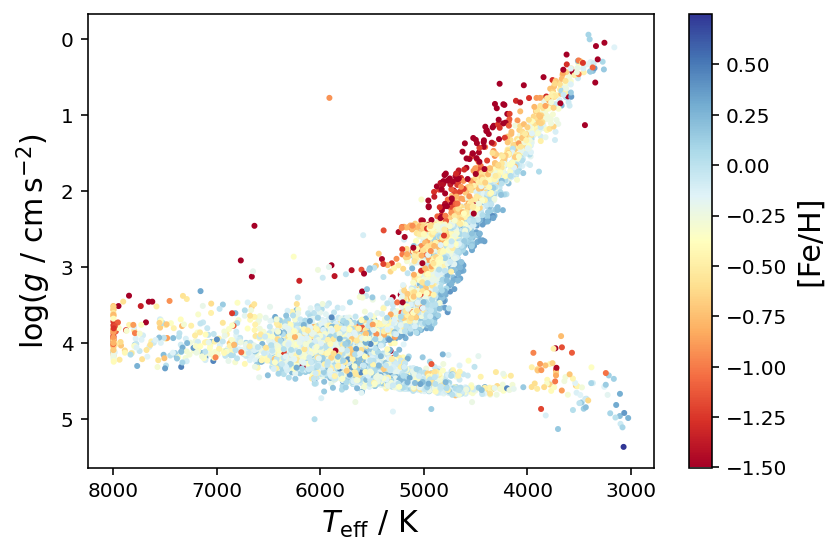

In [3]:
# Show Labels of selected subset
f, ax = plt.subplots()
s = ax.scatter(
    dr4_labels['teff'],
    dr4_labels['logg'],
    c = dr4_labels['fe_h'],
    cmap = 'RdYlBu',
    s = 4,
    vmin = -1.5
)
ax.set_xlabel(r'$T_\mathrm{eff}~/~\mathrm{K}$',fontsize=15)
ax.set_ylabel(r'$\log (g~/~\mathrm{cm\,s^{-2}})$',fontsize=15)
ax.set_xlim(ax.get_xlim()[::-1])
ax.set_ylim(ax.get_ylim()[::-1])
cbar = plt.colorbar(s,ax=ax)
cbar.set_label('[Fe/H]',fontsize=15)
plt.tight_layout()
plt.savefig('figures/labels_teff_logg_feh.png',dpi=200,bbox_inches='tight')
plt.show()
plt.close()

### 2.2 Spectra and residuals

In [4]:
# Identify same wavelength to interpolate onto
wavelength_edges = dict()
for ccd in ['1','2','3','4']:
    wavelength_edges[ccd+'_s'] = []
    wavelength_edges[ccd+'_d'] = []
    wavelength_edges[ccd+'_e'] = []

missing_spectra = [] # should stay empty, since we selected bad stars / low quality spectra with flags < 2**10

# Interpolate onto same wavelength
for sobject_id in dr4_labels['sobject_id']:
    
    try:
        spectrum = Table.read('spectra/'+str(sobject_id)[:6]+'/'+str(sobject_id)+'/'+str(sobject_id)+'_allstar_fit_spectrum.fits')
    
        for ccd in ['1','2','3','4']:

            in_ccd = (spectrum['wave'] > (int(ccd)+3)*1000) & (spectrum['wave'] < (int(ccd)+4)*1000)

            wavelength_edges[ccd+'_s'].append(spectrum['wave'][in_ccd][0])
            wavelength_edges[ccd+'_d'].append(spectrum['wave'][in_ccd][1]-spectrum['wave'][in_ccd][0])
            wavelength_edges[ccd+'_e'].append(spectrum['wave'][in_ccd][-1])

    except:
        missing_spectra.append(sobject_id)

print(str(len(missing_spectra))+' stars without useful spectra')
        
# Now limit the dr4_labels to those with available spectra
stars_with_available_spectra = [sobject_id not in missing_spectra for sobject_id in dr4_labels['sobject_id']]
dr4_labels = dr4_labels[stars_with_available_spectra]

residual_wavelength = []

for ccd in ['1','2','3','4']:
    wmin = np.round(np.max(wavelength_edges[ccd+'_s']),4)
    wdelta = np.round(np.median(wavelength_edges[ccd+'_d']),4)
    wmax = np.round(np.min(wavelength_edges[ccd+'_e']),4)
    
    residual_wavelength.append(np.arange(wmin,wmax,wdelta))
    print(str(wmin)+'..'+str(wdelta)+'..'+str(wmax))

residual_wavelength = np.concatenate((residual_wavelength))

40 stars without useful spectra
4719.0299..0.046..4893.8808
5655.5298..0.0547..5863.0182
6486.0104..0.0631..6726.4572
7689.1261..0.0735..7874.3127


In [5]:
residual_flux = []
residual_ivar = []

# Interpolate onto same wavelength
for sobject_id in dr4_labels['sobject_id']:
    
    spectrum = Table.read('spectra/'+str(sobject_id)[:6]+'/'+str(sobject_id)+'/'+str(sobject_id)+'_allstar_fit_spectrum.fits')

    residual_flux.append(np.interp(residual_wavelength,spectrum['wave'],spectrum['sob']-spectrum['smod']))
    residual_ivar.append(1./(np.interp(residual_wavelength,spectrum['wave'],spectrum['uob']))**2)

residual_flux = np.array(residual_flux)
residual_ivar = np.array(residual_ivar)

In [6]:
np.shape(residual_flux),np.shape(residual_ivar)

((7511, 13927), (7511, 13927))

## 3. Analysis

### 3.1 Stellar parameters -> 1D -> 3D implications?

In [7]:
label_names = ['teff','logg','fe_h']

# cannon_labels = np.array(x dr4_labels[label_names])
# cannon_labels

cannon_labels = np.array([[x[0],x[1],x[2]] for x in dr4_labels[label_names]])
cannon_labels

array([[ 6.20356592e+03,  4.25325489e+00, -2.20364109e-02],
       [ 5.81064209e+03,  4.26503229e+00,  2.80773304e-02],
       [ 5.78977148e+03,  4.31099892e+00, -4.07326043e-01],
       ...,
       [ 5.18908496e+03,  4.31192398e+00, -1.04418345e-01],
       [ 5.51677783e+03,  4.37211847e+00, -2.71069378e-01],
       [ 5.90278418e+03,  4.01220322e+00, -4.15961981e-01]], dtype=float32)

In [8]:
tc_res_tlf = tc.CannonModel(
    cannon_labels,
    residual_flux, residual_ivar,
    vectorizer=tc.vectorizer.PolynomialVectorizer(list(label_names), 2),dispersion=residual_wavelength)

In [9]:
tc_res_tlf_theta, tc_res_tlf_s2, tc_res_tlf_metadata = tc_res_tlf.train(threads=1)

2025-07-04 13:51:13,901 [INFO] Training 3-label CannonModel with 7511 stars and 13927 pixels/star
stty: stdin isn't a terminal
2025-07-04 13:51:14,068 [DEBUG] Couldn't get screen size. Progressbar may look odd.


[====================================================================================================] 100% (42s)                                  


In [10]:
tc_res_tlf.write('models/tc_res_tlf.model',overwrite=True)

In [11]:
tc_res_tlf_out, tc_res_tlf_cov, tc_res_tlf_meta = tc_res_tlf.test(residual_flux, residual_ivar)

stty: stdin isn't a terminal
2025-07-04 13:51:56,442 [DEBUG] Couldn't get screen size. Progressbar may look odd.
2025-07-04 13:51:56,443 [INFO] Running test step on 7511 spectra


[====================================================================================================] 100% (129s)                               


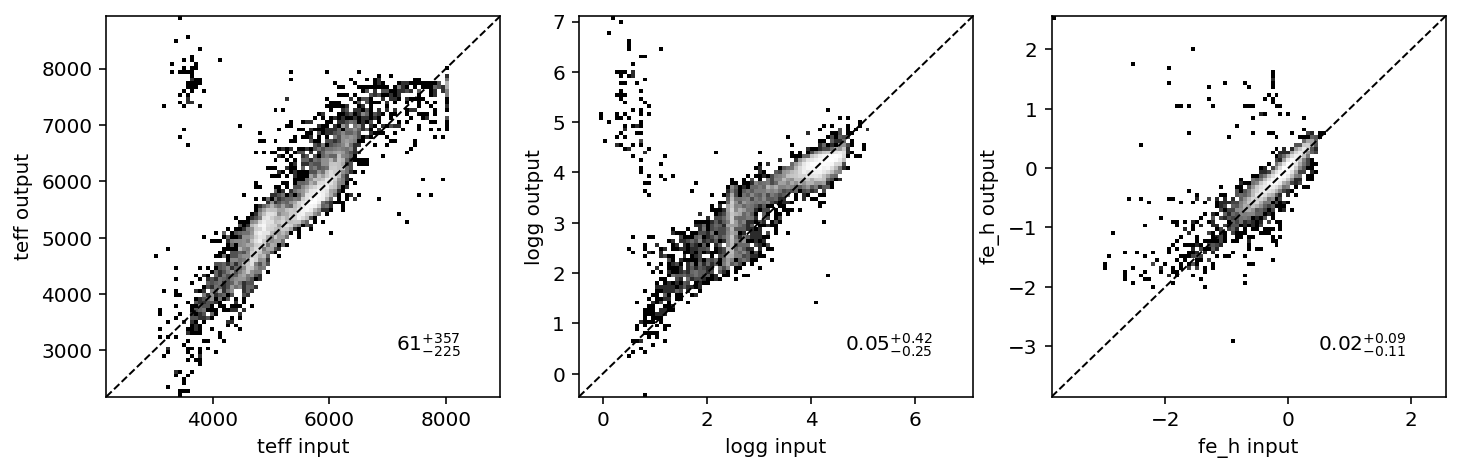

In [54]:
f, gs = plt.subplots(1,len(label_names),figsize=(4*len(label_names),3.5))

for index, label in enumerate(label_names):
    ax = gs[index]
    
    xy_min = np.min([np.min(cannon_labels[:,index]),np.min(tc_res_tlf_out[:,index])])
    xy_max = np.max([np.max(cannon_labels[:,index]),np.max(tc_res_tlf_out[:,index])])
    ax.set_xlim(xy_min,xy_max)
    ax.set_ylim(xy_min,xy_max)

    ax.hist2d(
        cannon_labels[:,index],
        tc_res_tlf_out[:,index],
        cmin = 1,
        cmap = 'Greys_r',
        bins = np.linspace(xy_min,xy_max,100),
        norm = LogNorm()
    )

    percentiles = np.percentile(tc_res_tlf_out[:,index] - cannon_labels[:,index], q = [16,50,84])
    if label == 'teff':
        percentiles = np.array(np.round(percentiles),dtype=int)
    else:
        percentiles = np.round(percentiles,2)

    ax.text(0.9,0.1,r'$'+str(percentiles[1])+'_{-'+str(percentiles[1]-percentiles[0])+'}^{+'+str(percentiles[2]-percentiles[1])+'}$',va='bottom',ha='right',transform=ax.transAxes)
    
    ax.set_xlabel(label+' input')
    ax.set_ylabel(label+' output')
    ax.plot([xy_min,xy_max],[xy_min,xy_max],c='k',lw=1,ls='dashed')

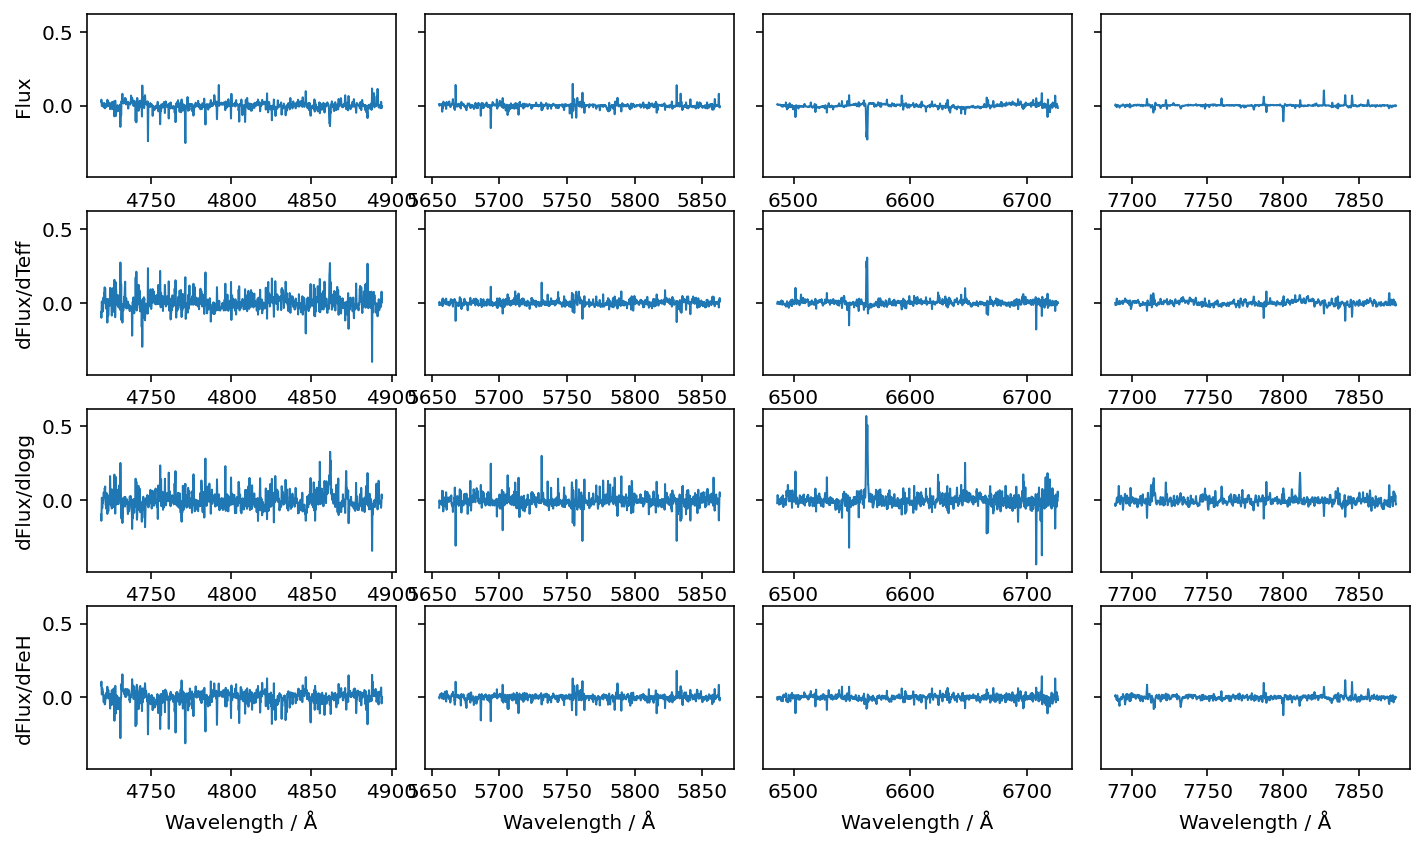

In [80]:
f, gs = plt.subplots(4,4,figsize=(10,6),sharey=True)
gs = gs.flatten()

for index, label in enumerate(['Flux','dFlux/dTeff','dFlux/dlogg','dFlux/dFeH']):
    for ccd in [1,2,3,4]:
        ax = gs[index*4+ccd-1]
        in_ccd = (residual_wavelength > (int(ccd)+3)*1000) & (residual_wavelength < (int(ccd)+4)*1000)
        ax.plot(
            residual_wavelength[in_ccd],
            tc_res_tlf_theta[in_ccd,index],
            lw = 1
        )
        if ccd == 1:
            ax.set_ylabel(label)
        if index == 3:
            ax.set_xlabel('Wavelength / Å')

plt.tight_layout(w_pad=0,h_pad=0)
plt.savefig('figures/tc_res_tlf_theta.pdf',dpi=200,bbox_inches='tight')
            
# ax = gs[0]

# ax = gs[1]
# ax.plot(
#     tc_res_tlf_theta[:,1]
# )
# ax = gs[2]
# ax.plot(
#     tc_res_tlf_theta[:,2]
# )
# ax = gs[3]
# ax.plot(
#     tc_res_tlf_theta[:,3]
# )

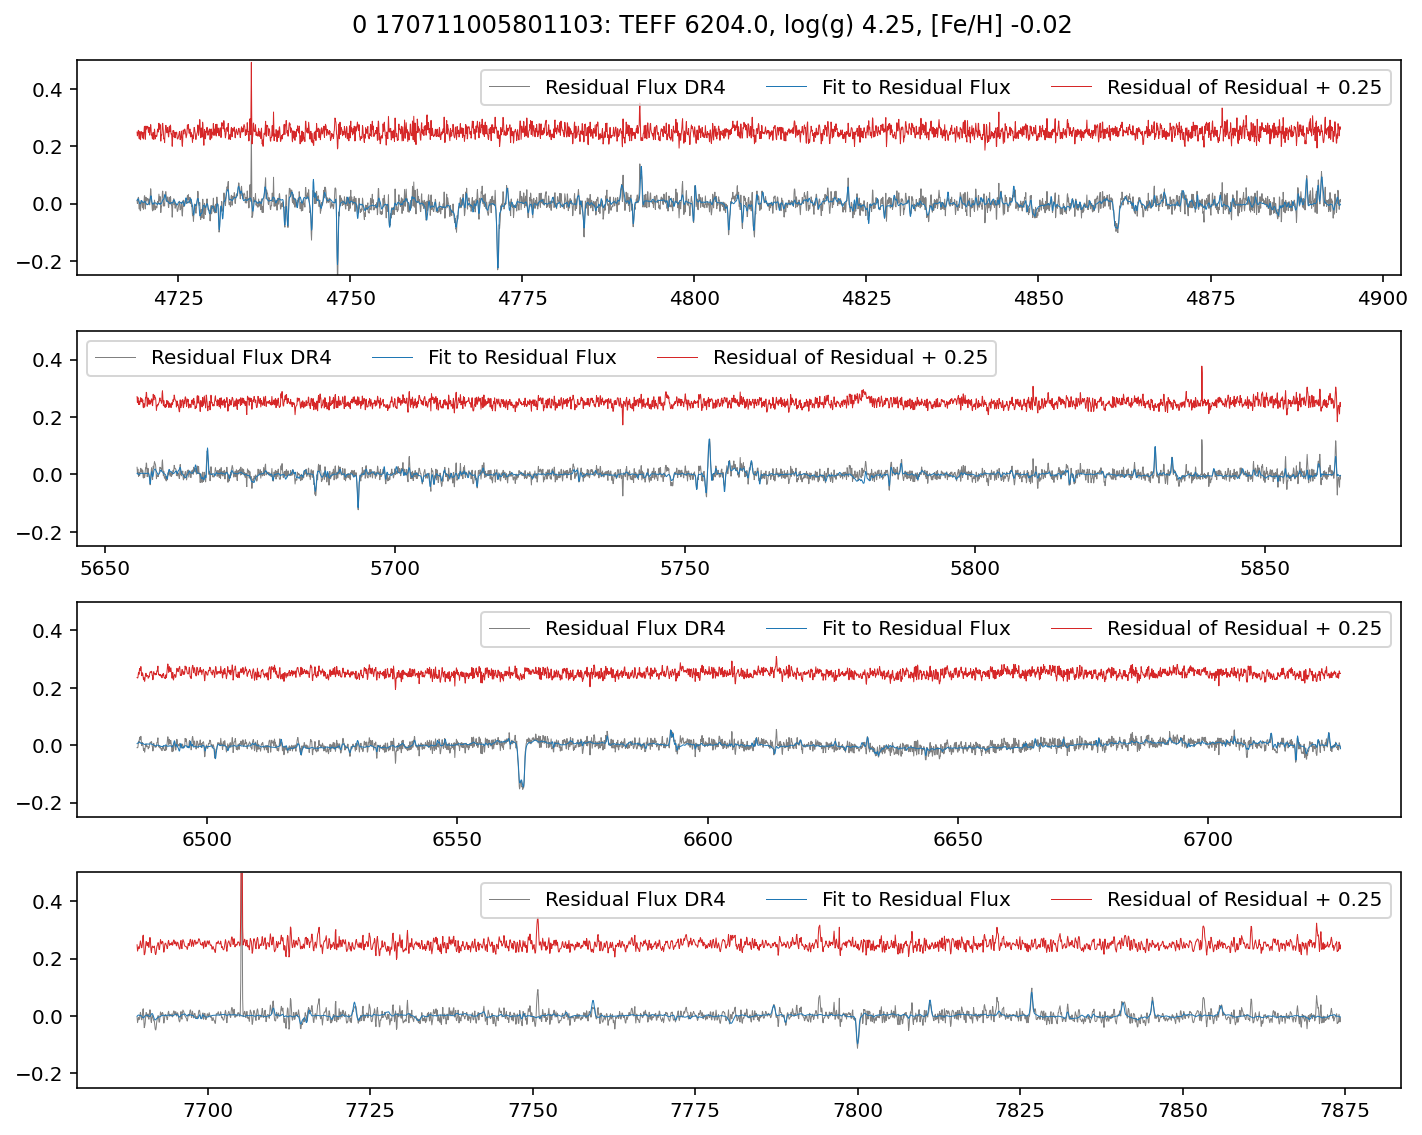

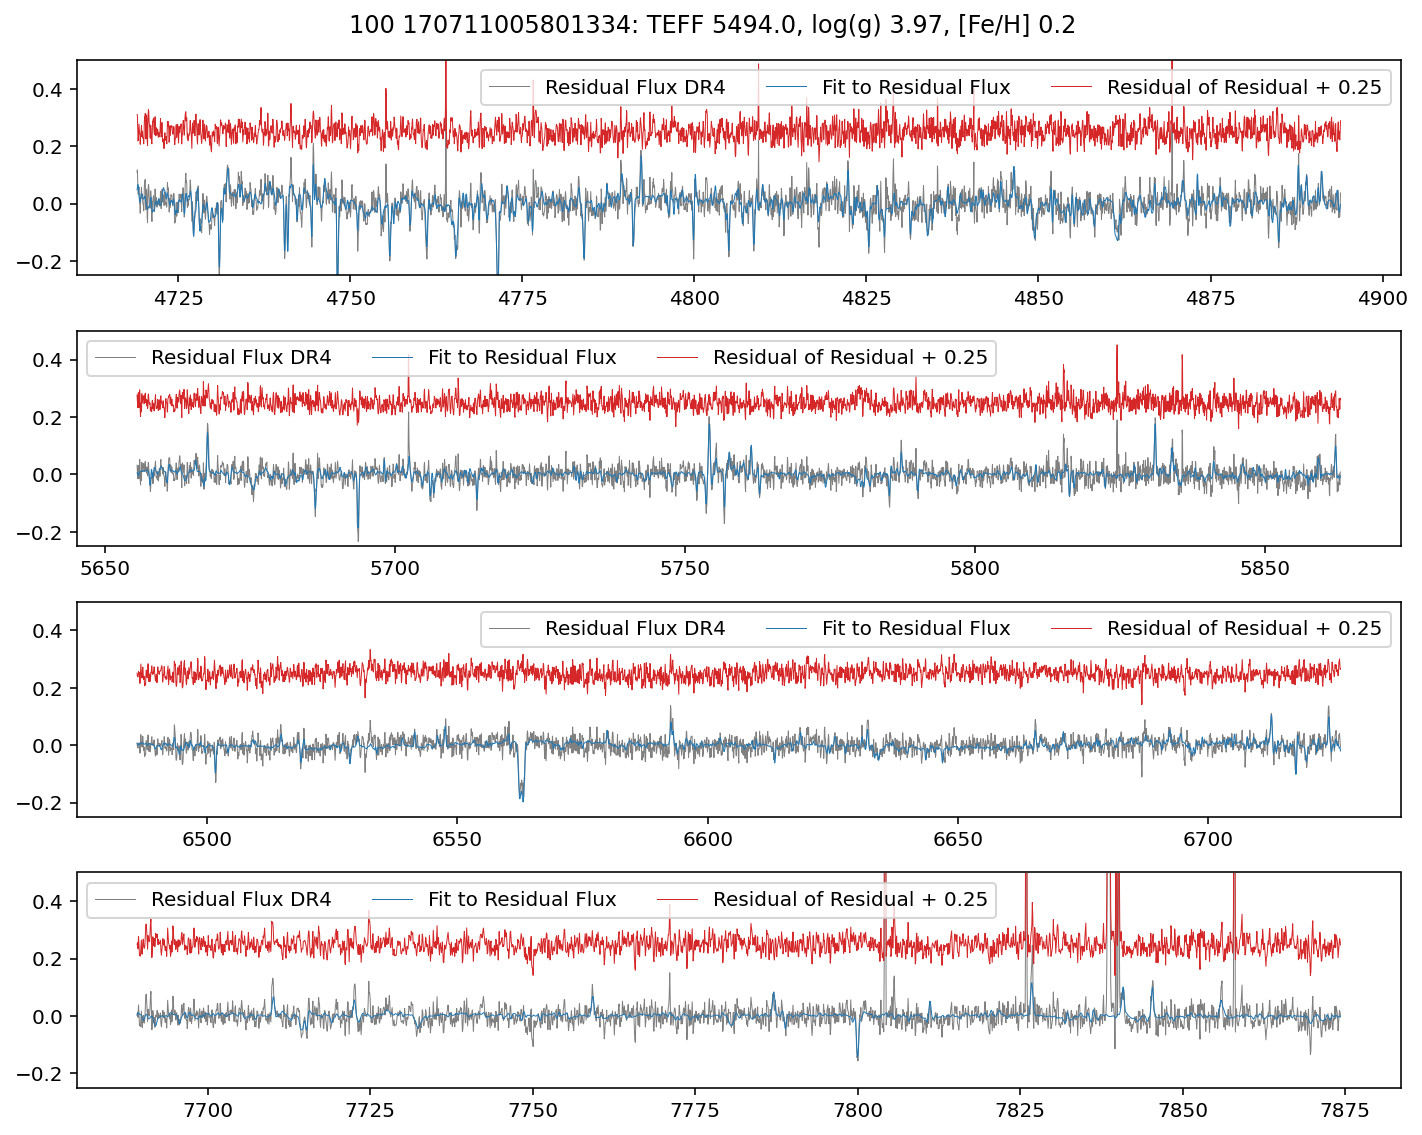

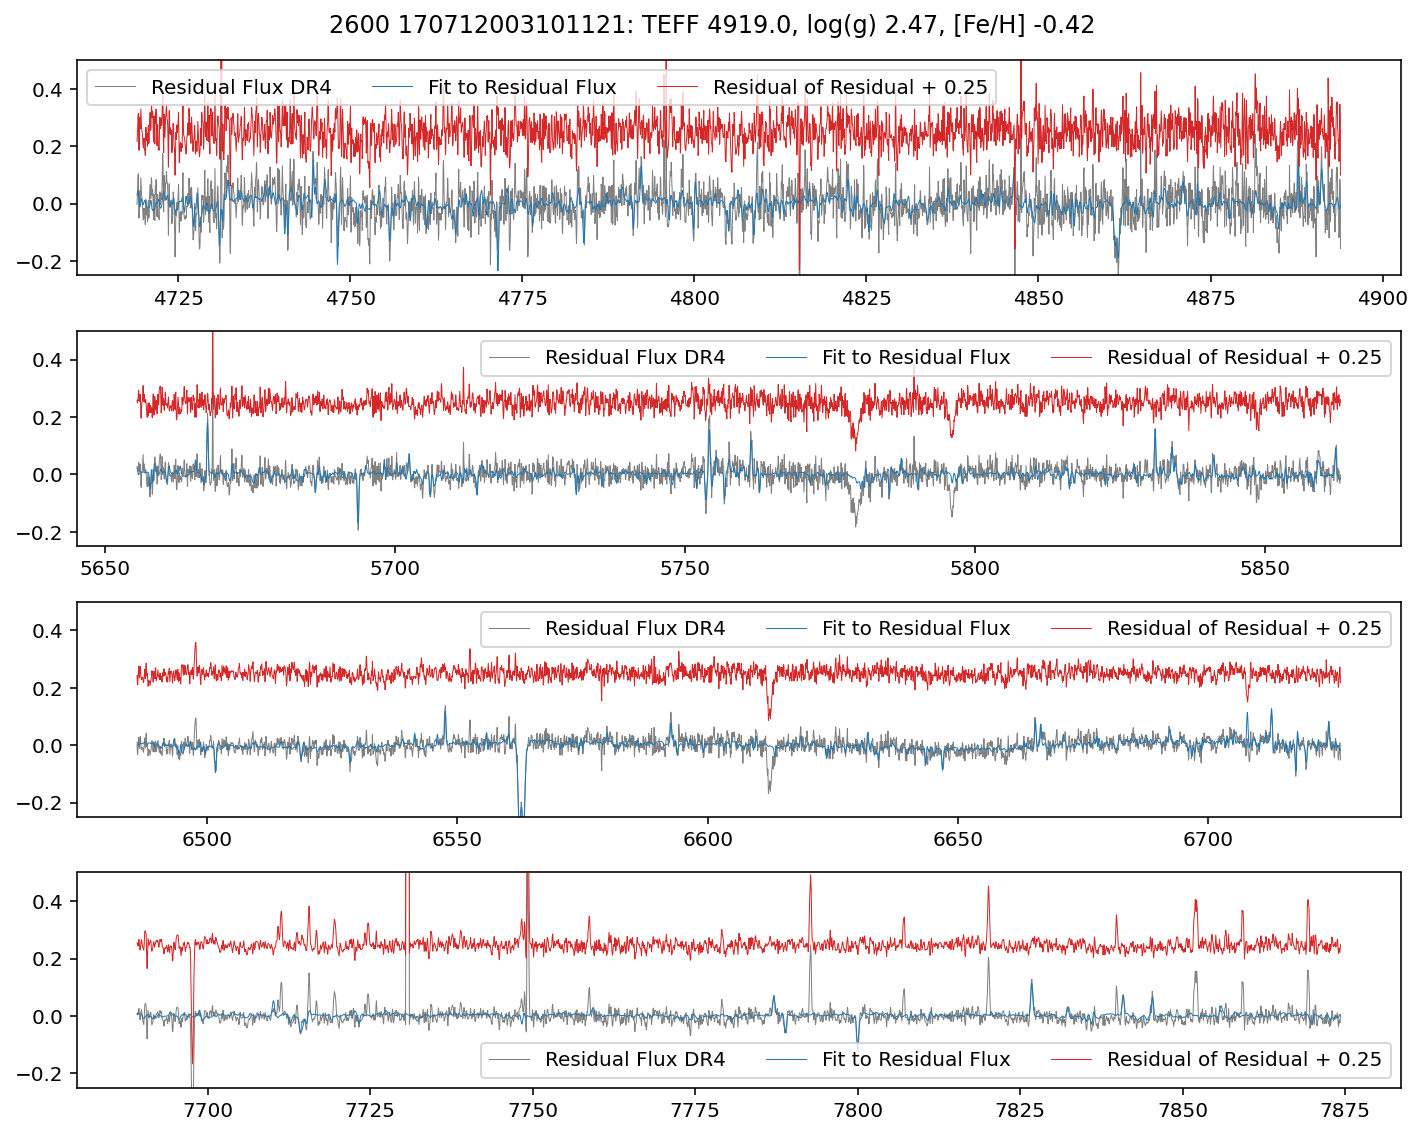

In [58]:
def plot_fit(star_index):
    residual_model_flux = tc_res_tlf.__call__(tc_res_tlf_out[star_index])

    f, gs = plt.subplots(4,1,figsize=(10,8),sharey=True)
    for ccd in [1,2,3,4]:
        in_ccd = (residual_wavelength > (int(ccd)+3)*1000) & (residual_wavelength < (int(ccd)+4)*1000)
        ax = gs[ccd-1]
        ax.plot(
            residual_wavelength[in_ccd],
            residual_flux[star_index][in_ccd],
            c = 'grey', label = 'Residual Flux DR4', lw=0.5
        )
        ax.plot(
            residual_wavelength[in_ccd],
            residual_model_flux[in_ccd],
            c = 'C0', label = 'Fit to Residual Flux', lw=0.5
        )
        ax.plot(
            residual_wavelength[in_ccd],
            residual_flux[star_index][in_ccd] - residual_model_flux[in_ccd]+0.25,
            c = 'C3', label = 'Residual of Residual + 0.25', lw=0.5
        )
        ax.legend(ncol=3)
    ax.set_ylim(-0.25,0.5)
    f.suptitle(str(star_index)+' '+str(dr4_labels['sobject_id'][star_index])+': TEFF '+str(np.round(dr4_labels['teff'][star_index]))+', log(g) '+str(np.round(dr4_labels['logg'][star_index],2))+', [Fe/H] '+str(np.round(dr4_labels['fe_h'][star_index],2)))

    plt.tight_layout()
    
    plt.savefig('figures/residuals_'+str(dr4_labels['sobject_id'][star_index])+'.pdf',bbox_inches='tight',dpi=200)
    plt.show()
    plt.close()
    
to_plot = [
    0, # first star -> Halpha and Hbeta as well as line at 7800 and 5755
    100, # missed lines in CCD1; emission lines in CCD4
    2600, # DIBs & KI
]

for index in to_plot:#np.arange(0,7000,100):
    plot_fit(index)

### 3.2 logRHK or X_lum -> activity?

### 3.3 Extinction -> ISM density